In [1]:
from fastai.vision.all import *
from fastai.callback.fp16 import *

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from collections import Counter
from torch.utils.data import WeightedRandomSampler

import numpy as np
import pandas as pd

import timm

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
fname = '/content/drive/MyDrive/endocellgraph'

In [3]:
dblock = DataBlock(blocks = (ImageBlock, CategoryBlock),
                   get_items = get_image_files,
                   get_y = parent_label,
                   splitter = RandomSplitter(seed=42),
                   item_tfms = Resize(224),
                   batch_tfms = aug_transforms(mult=1.5, flip_vert=True, max_rotate=180, max_zoom=1.1, max_lighting=0.3))

In [4]:
dls = dblock.dataloaders(fname, bs=64)

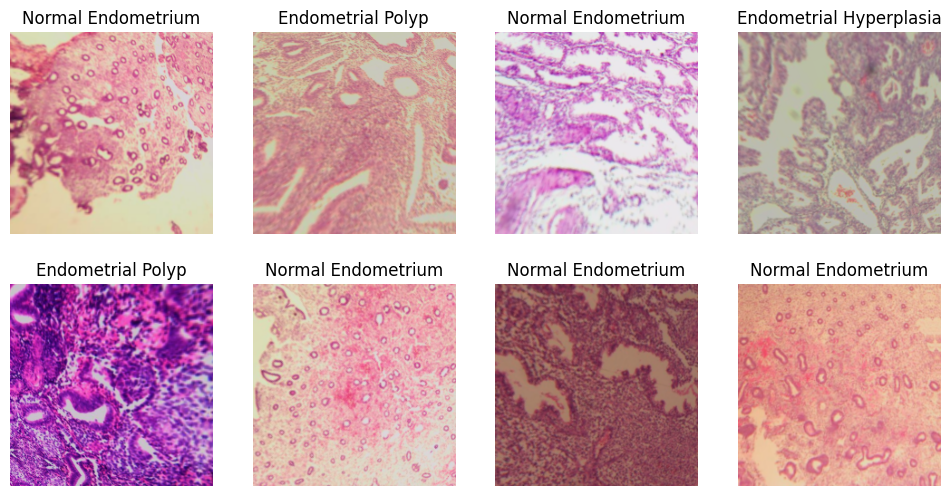

In [5]:
dls.show_batch(max_n = 8)

In [6]:
timm.list_models('swin**')

['swin_base_patch4_window7_224',
 'swin_base_patch4_window12_384',
 'swin_large_patch4_window7_224',
 'swin_large_patch4_window12_384',
 'swin_s3_base_224',
 'swin_s3_small_224',
 'swin_s3_tiny_224',
 'swin_small_patch4_window7_224',
 'swin_tiny_patch4_window7_224',
 'swinv2_base_window8_256',
 'swinv2_base_window12_192',
 'swinv2_base_window12to16_192to256',
 'swinv2_base_window12to24_192to384',
 'swinv2_base_window16_256',
 'swinv2_cr_base_224',
 'swinv2_cr_base_384',
 'swinv2_cr_base_ns_224',
 'swinv2_cr_giant_224',
 'swinv2_cr_giant_384',
 'swinv2_cr_huge_224',
 'swinv2_cr_huge_384',
 'swinv2_cr_large_224',
 'swinv2_cr_large_384',
 'swinv2_cr_small_224',
 'swinv2_cr_small_384',
 'swinv2_cr_small_ns_224',
 'swinv2_cr_small_ns_256',
 'swinv2_cr_tiny_224',
 'swinv2_cr_tiny_384',
 'swinv2_cr_tiny_ns_224',
 'swinv2_large_window12_192',
 'swinv2_large_window12to16_192to256',
 'swinv2_large_window12to24_192to384',
 'swinv2_small_window8_256',
 'swinv2_small_window16_256',
 'swinv2_tiny_wi

In [7]:
metrics = [accuracy,
           Precision(average='macro'),
           Recall(average='macro'),
           F1Score(average='macro')]

In [10]:
learn = vision_learner(dls, convnext_small, metrics=metrics).to_fp16()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Small_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Small_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/convnext_small-0c510722.pth" to /root/.cache/torch/hub/checkpoints/convnext_small-0c510722.pth


100%|██████████| 192M/192M [00:01<00:00, 104MB/s] 


<div></div>

SuggestedLRs(valley=0.010964781977236271)

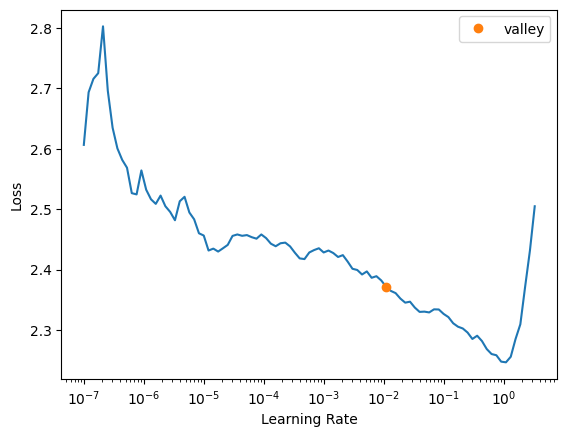

In [11]:
learn.lr_find()

In [12]:
learn.fit_one_cycle(15, slice(1e-2, 1e-1))

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,2.089641,1.156405,0.481873,0.442173,0.414553,0.410522,01:53
1,1.758733,1.030864,0.548338,0.515755,0.495002,0.473902,00:33
2,1.424453,0.878441,0.620846,0.601259,0.621279,0.593159,00:31
3,1.302518,0.956993,0.584592,0.631427,0.503816,0.458956,00:32
4,1.182247,0.926272,0.601208,0.711997,0.500552,0.511486,00:32
5,1.140215,0.815365,0.655589,0.756444,0.600464,0.568270,00:32
6,1.078523,0.834138,0.632931,0.671185,0.573475,0.596721,00:34
7,1.026831,1.041828,0.560423,0.692038,0.441568,0.456925,00:32
8,0.975854,0.811247,0.645015,0.707251,0.690530,0.655653,00:32
9,0.932670,0.842100,0.655589,0.714032,0.584983,0.615242,00:32


In [13]:
preds, targs = learn.tta()

y_pred = preds.argmax(dim=1)

from sklearn.metrics import (
    recall_score,
    roc_auc_score,
    confusion_matrix
)

import numpy as np

# Sensitivity
sensitivity = recall_score(
    targs.cpu(),
    y_pred.cpu(),
    average='macro'
)

# ROC-AUC
roc_auc = roc_auc_score(
    targs.cpu(),
    preds.cpu(),
    multi_class='ovr',
    average='macro'
)

# Specificity
cm = confusion_matrix(
    targs.cpu(),
    y_pred.cpu()
)

specificities = []

for i in range(len(cm)):

    TP = cm[i,i]
    FN = cm[i,:].sum() - TP
    FP = cm[:,i].sum() - TP
    TN = cm.sum() - TP - FN - FP

    specificities.append(
        TN/(TN+FP)
    )

specificity = np.mean(specificities)

print(f"Sensitivity : {sensitivity:.4f}")
print(f"Specificity : {specificity:.4f}")
print(f"ROC-AUC     : {roc_auc:.4f}")

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time


<div></div>

Sensitivity : 0.7251
Specificity : 0.9048
ROC-AUC     : 0.9230
